# Hybrid CNN + Handcrafted Feature Ranking Model

## 背景
- 画像ベースPairwise Ranker (EfficientNet-B0 fine-tune) → Top-5 Precision 0%（患者identityを学習）
- 15次元手動特徴量のルールベーススコアリング → 47-54% Top-5 Precision
- Frozen EfficientNet-B0 (ImageNet) + Handcrafted → 8.2% (CNN寄与ゼロ)

## アプローチ
Frozen backbone (RETFound or EfficientNet-B0) の特徴抽出をPCAで圧縮し、15次元の手動特徴量と結合。
軽量MLP（~1,700パラメータ）でペアワイズランキング。

### Backbone選択
- **RETFound** (default): ViT-Large, 160万枚カラー眼底写真でMAE事前学習, 1024-dim
- **EfficientNet-B0**: ImageNet事前学習, 1280-dim

```
[Frozen Backbone]               [15 Handcrafted Features]
(RETFound 1024-dim /                     |
 EfficientNet 1280-dim)          MinMaxScaler (per-fold)
        |                                |
   StandardScaler + PCA (per-fold)       |
   → best_dim                            |
        |                                |
        +----------- concat ------------+
                       |
                  (best_dim+15) input
                       |
                 BatchNorm1d → Linear → ReLU → Dropout(0.5)
                       |
                 Linear → ReLU → Linear → score
```

## 評価
- Leave-One-Video-Out 22-fold CV
- Top-5 Precision / Recall / MRR / NDCG@5
- ルールベース(47-54%) vs Hybrid の比較
- EfficientNet-B0 Hybrid vs RETFound Hybrid の比較

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Optional
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from tqdm import tqdm
import cv2
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

plt.rcParams['font.family'] = 'MS Gothic'

# ============================================================
# Config
# ============================================================
@dataclass
class HybridConfig:
    base_dir: Path = Path(r'C:\Users\ykita\ROP_AI_project\ROP_project\bestimage_validation')

    # Feature columns (15 handcrafted features)
    feature_columns: List[str] = field(default_factory=lambda: [
        'retina_ratio', 'retina_area', 'disc_detected',
        'disc_edge_coverage_ratio', 'disc_area_ratio', 'disc_center_dist_ratio',
        'disc_pos_ok', 'mbss_L_multi', 'mbss_HF_ratio', 'mbss_Spec_centroid',
        'mbss_Grad_p90', 'mbss_score', 'disc_core_score', 'disc_ring_score', 'S_mean',
    ])

    rule_based_weights: dict = field(default_factory=lambda: {
        'retina_ratio': 0.4, 'mbss_Grad_p90': 0.4, 'mbss_score': 0.2,
    })

    # Backbone selection: 'retfound' or 'efficientnet_b0'
    backbone: str = 'retfound'
    cnn_feature_dim: int = 1024   # RETFound: 1024, EfficientNet: 1280
    img_size: int = 224           # RETFound: 224, EfficientNet: 384
    pca_dim: int = 32  # PCA reduced dimension

    # RETFound weights path
    retfound_weights_path: Path = Path(r'C:\Users\ykita\ROP_AI_project\ROP_project\models\RETFound_cfp_weights.pth')

    # Hybrid MLP
    hidden_dims: List[int] = field(default_factory=lambda: [32, 16])
    dropout: float = 0.5

    # Data settings
    top_k_candidates: int = 100
    num_negatives_per_positive: int = 10
    hard_negative_ratio: float = 0.5

    # Training
    learning_rate: float = 1e-3
    margin: float = 1.0
    batch_size: int = 64
    num_epochs: int = 100
    early_stopping_patience: int = 10
    weight_decay: float = 1e-4

    # Evaluation
    top_k_eval: int = 5
    seed: int = 42

    def __post_init__(self):
        self.results_dir = self.base_dir / 'validation_results'
        self.merged_csv_path = self.results_dir / 'merged_with_disc.csv'
        self.lens_crops_dir = self.base_dir / 'lens_crops'
        self.metadata_csv_path = self.lens_crops_dir / 'metadata.csv'
        self.output_dir = self.base_dir / 'hybrid_ranking_outputs'

        # Set backbone-dependent params
        if self.backbone == 'retfound':
            self.cnn_feature_dim = 1024
            self.img_size = 224
            self.cnn_cache_path = self.lens_crops_dir / 'cnn_features_retfound.npz'
        else:  # efficientnet_b0
            self.cnn_feature_dim = 1280
            self.img_size = 384
            self.cnn_cache_path = self.lens_crops_dir / 'cnn_features_effb0.npz'

config = HybridConfig()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'Backbone: {config.backbone} ({config.cnn_feature_dim}-dim, img_size={config.img_size})')
print(f'PCA dim: {config.pca_dim}')
print(f'Cache: {config.cnn_cache_path.name}')
print(f'Hybrid input dim: {config.pca_dim + len(config.feature_columns)}')
print(f'MLP: {config.pca_dim + len(config.feature_columns)} -> {config.hidden_dims} -> 1')

Device: cuda
GPU: Quadro RTX 5000
Backbone: retfound (1024-dim, img_size=224)
PCA dim: 32
Cache: cnn_features_retfound.npz
Hybrid input dim: 47
MLP: 47 -> [32, 16] -> 1


In [32]:
# ============================================================
# Cell 3: CNN Feature Extraction (Frozen Backbone)
# ============================================================

def get_val_transforms(img_size: int = 224):
    return A.Compose([
        A.Resize(img_size, img_size),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])


class InferenceDataset(Dataset):
    """Dataset for loading lens crop images."""
    def __init__(self, image_paths: List[str], img_size: int = 224, transforms=None):
        self.image_paths = image_paths
        self.img_size = img_size
        self.transforms = transforms

    def __len__(self) -> int:
        return len(self.image_paths)

    def __getitem__(self, idx: int) -> Dict:
        path = self.image_paths[idx]
        img = cv2.imread(path)
        if img is None:
            return {'image': torch.zeros(3, self.img_size, self.img_size), 'path': path}
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if self.transforms:
            img = self.transforms(image=img)['image']
        return {'image': img, 'path': path}


def _load_backbone(backbone_name: str, config: 'HybridConfig', device: torch.device):
    """Load frozen backbone model for feature extraction."""
    if backbone_name == 'retfound':
        from retfound_utils import load_retfound
        backbone = load_retfound(
            config.retfound_weights_path,
            device=device,
            img_size=config.img_size,
        )
    else:
        # EfficientNet-B0 (ImageNet)
        backbone = timm.create_model(backbone_name, pretrained=True, num_classes=0, global_pool='avg')
        backbone = backbone.to(device)
        backbone.eval()
        for param in backbone.parameters():
            param.requires_grad = False
    return backbone


def _extract_features(backbone, images: torch.Tensor, backbone_name: str) -> torch.Tensor:
    """Extract feature vectors from backbone. Returns (B, feature_dim)."""
    if backbone_name == 'retfound':
        # Use forward_features to get 1024-dim patch-averaged features
        return backbone.forward_features(images)
    else:
        # timm model with num_classes=0 returns pooled features directly
        return backbone(images)


def extract_cnn_features(
    metadata_df: pd.DataFrame,
    cache_path: Path,
    config: 'HybridConfig',
    batch_size: int = 32,
    device: torch.device = torch.device('cuda'),
) -> Dict[str, np.ndarray]:
    """
    Extract CNN features from all lens crops using frozen backbone.
    Results are cached to .npz for fast reloading.

    Returns:
        dict: image_name -> feature vector (1024-dim for RETFound, 1280-dim for EfficientNet)
    """
    # Load from cache if available
    if cache_path.exists():
        print(f'Loading cached CNN features from {cache_path}')
        data = np.load(cache_path, allow_pickle=True)
        features_dict = dict(zip(data['image_names'].tolist(), data['features']))
        print(f'  Loaded {len(features_dict)} features ({data["features"].shape[1]}-dim)')
        return features_dict

    print(f'Extracting CNN features with {config.backbone}...')

    # Filter to images with valid crop paths
    valid_df = metadata_df[metadata_df['crop_width'] > 100].copy()
    image_paths = valid_df['crop_path'].tolist()
    image_names = valid_df['image_name'].tolist()
    print(f'  Processing {len(image_paths)} images...')

    # Load frozen backbone
    backbone = _load_backbone(config.backbone, config, device)

    transforms = get_val_transforms(config.img_size)
    dataset = InferenceDataset(image_paths, img_size=config.img_size, transforms=transforms)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    all_features = []
    all_names = []
    with torch.no_grad():
        for batch in tqdm(loader, desc=f'Extracting {config.backbone} features'):
            images = batch['image'].to(device)
            features = _extract_features(backbone, images, config.backbone)
            all_features.append(features.cpu().numpy())
            for p in batch['path']:
                fname = Path(p).name
                orig_name = fname.replace('_lens.jpg', '.jpg')
                all_names.append(orig_name)

    all_features = np.concatenate(all_features, axis=0)
    print(f'  Extracted features shape: {all_features.shape}')

    # Save cache
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(
        cache_path,
        image_names=np.array(all_names),
        features=all_features,
    )
    print(f'  Saved cache to {cache_path}')

    features_dict = dict(zip(all_names, all_features))
    return features_dict

In [33]:
# ============================================================
# Cell 4: Data Loading + CNN Feature Extraction
# ============================================================

# Load handcrafted feature data
df = pd.read_csv(config.merged_csv_path)
print(f'Loaded merged data: {df.shape}')

# Load human selections
xlsx_path = config.results_dir / 'ベストショット一致率20260104.xlsx'
if xlsx_path.exists():
    df_excel = pd.read_excel(xlsx_path, sheet_name=0)
    human_selections = {}
    for case_id in df_excel['動画番号'].unique():
        case_data = df_excel[df_excel['動画番号'] == case_id]
        yf_images, hk_images = [], []
        for _, row in case_data.iterrows():
            if pd.notna(row.get('YF')):
                yf_images.append(f'IMG_{case_id}_{int(row["YF"]):04d}.jpg')
            if pd.notna(row.get('HK')):
                hk_images.append(f'IMG_{case_id}_{int(row["HK"]):04d}.jpg')
        human_selections[case_id] = list(set(yf_images[:5] + hk_images[:5]))
    # Mark human selections
    if 'is_human_top' not in df.columns:
        df['is_human_top'] = False
    for case_id, selected in human_selections.items():
        mask = (df['case_id'] == case_id) & (df['image_name'].isin(selected))
        df.loc[mask, 'is_human_top'] = True

case_ids = sorted(df['case_id'].unique().tolist())
print(f'Cases: {len(case_ids)}, Human-selected: {df["is_human_top"].sum()}')

# Load metadata for lens crops
meta_df = pd.read_csv(config.metadata_csv_path)
print(f'Lens crops metadata: {meta_df.shape}')

# Extract / load CNN features
cnn_features = extract_cnn_features(
    meta_df, config.cnn_cache_path,
    config=config,
    device=device,
)
print(f'CNN features available for {len(cnn_features)} images')

# Check coverage
n_match = sum(1 for name in df['image_name'] if name in cnn_features)
print(f'CNN feature coverage in merged data: {n_match}/{len(df)} ({n_match/len(df)*100:.1f}%)')

Loaded merged data: (6689, 27)
Cases: 22, Human-selected: 138
Lens crops metadata: (6689, 12)
Loading cached CNN features from C:\Users\ykita\ROP_AI_project\ROP_project\bestimage_validation\lens_crops\cnn_features_retfound.npz
  Loaded 6676 features (1024-dim)
CNN features available for 6676 images
CNN feature coverage in merged data: 6676/6689 (99.8%)


In [34]:
# ============================================================
# Cell 5: FoldPreprocessor (per-fold scaling + PCA)
# ============================================================

class FoldPreprocessor:
    """Per-fold preprocessing: StandardScaler->PCA for CNN features, MinMaxScaler for handcrafted."""

    def __init__(self, feature_columns: List[str], pca_dim: int = 32, cnn_feature_dim: int = 1024):
        self.feature_columns = feature_columns
        self.pca_dim = pca_dim
        self.cnn_feature_dim = cnn_feature_dim
        self.cnn_scaler = StandardScaler()
        self.pca = PCA(n_components=pca_dim)
        self.hand_scaler = MinMaxScaler()
        self.fitted = False

    def _get_handcrafted(self, df: pd.DataFrame) -> np.ndarray:
        """Extract 15-dim handcrafted features from dataframe."""
        features = []
        for col in self.feature_columns:
            if col in df.columns:
                vals = df[col].values.copy().astype(float)
                if col in ['disc_detected', 'disc_pos_ok']:
                    vals = np.where(np.isnan(vals), 0, vals)
                else:
                    median_val = np.nanmedian(vals) if np.any(~np.isnan(vals)) else 0
                    vals = np.where(np.isnan(vals), median_val, vals)
            else:
                vals = np.zeros(len(df))
            features.append(vals)
        return np.stack(features, axis=1).astype(np.float32)

    def _get_cnn(self, df: pd.DataFrame, cnn_features: Dict[str, np.ndarray]) -> np.ndarray:
        """Get CNN feature vectors for images in df."""
        zero_vec = np.zeros(self.cnn_feature_dim, dtype=np.float32)
        vecs = []
        for name in df['image_name']:
            vecs.append(cnn_features.get(name, zero_vec))
        return np.stack(vecs, axis=0)

    def fit(self, train_df: pd.DataFrame, cnn_features: Dict[str, np.ndarray]):
        """Fit scalers and PCA on training data only."""
        # Handcrafted
        hand = self._get_handcrafted(train_df)
        self.hand_scaler.fit(hand)

        # CNN: StandardScaler -> PCA
        cnn = self._get_cnn(train_df, cnn_features)
        cnn_scaled = self.cnn_scaler.fit_transform(cnn)
        # Clamp PCA dim to min(n_samples, n_features)
        effective_dim = min(self.pca_dim, cnn_scaled.shape[0], cnn_scaled.shape[1])
        if effective_dim != self.pca_dim:
            self.pca = PCA(n_components=effective_dim)
        self.pca.fit(cnn_scaled)
        self.fitted = True

    def transform(self, df: pd.DataFrame, cnn_features: Dict[str, np.ndarray]) -> np.ndarray:
        """Transform features for a dataframe. Returns concatenated [pca_cnn | handcrafted]."""
        assert self.fitted, 'Call fit() first'

        # Handcrafted
        hand = self._get_handcrafted(df)
        hand_scaled = self.hand_scaler.transform(hand)

        # CNN
        cnn = self._get_cnn(df, cnn_features)
        cnn_scaled = self.cnn_scaler.transform(cnn)
        cnn_pca = self.pca.transform(cnn_scaled)

        return np.concatenate([cnn_pca, hand_scaled], axis=1).astype(np.float32)

    def transform_handcrafted_only(self, df: pd.DataFrame) -> np.ndarray:
        """Transform handcrafted features only (for ablation)."""
        assert self.fitted
        hand = self._get_handcrafted(df)
        return self.hand_scaler.transform(hand).astype(np.float32)

    @property
    def hybrid_dim(self) -> int:
        return self.pca.n_components_ + len(self.feature_columns)

print(f'FoldPreprocessor defined (cnn_feature_dim={config.cnn_feature_dim}).')

FoldPreprocessor defined (cnn_feature_dim=1024).


In [35]:
# ============================================================
# Cell 6: HybridPairwiseRanker (MLP)
# ============================================================

class HybridPairwiseRanker(nn.Module):
    """Lightweight MLP for pairwise ranking on hybrid features."""

    def __init__(self, input_dim: int = 47, hidden_dims: List[int] = [32, 16], dropout: float = 0.5):
        super().__init__()
        layers = [nn.BatchNorm1d(input_dim)]
        prev_dim = input_dim
        for i, h in enumerate(hidden_dims):
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.ReLU())
            if i < len(hidden_dims) - 1:
                layers.append(nn.Dropout(dropout))
            prev_dim = h
        layers.append(nn.Linear(prev_dim, 1))
        self.network = nn.Sequential(*layers)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x).squeeze(-1)

    def compute_pairwise_loss(
        self, pos_features: torch.Tensor, neg_features: torch.Tensor, margin: float = 1.0
    ) -> torch.Tensor:
        pos_scores = self.forward(pos_features)
        neg_scores = self.forward(neg_features)
        return F.margin_ranking_loss(
            pos_scores, neg_scores, target=torch.ones_like(pos_scores), margin=margin
        )

# Quick check
test_model = HybridPairwiseRanker(47, [32, 16], 0.5)
n_params = sum(p.numel() for p in test_model.parameters())
print(f'HybridPairwiseRanker: {n_params} parameters')
del test_model

HybridPairwiseRanker: 2175 parameters


In [36]:
# ============================================================
# Cell 7: Pair Sample Generation
# ============================================================

def compute_rule_based_score(case_df: pd.DataFrame, weights: dict) -> pd.Series:
    """Compute rule-based score for top-K filtering."""
    score = pd.Series(0.0, index=case_df.index)
    for col, w in weights.items():
        if col in case_df.columns:
            score += w * case_df[col].fillna(0)
    return score


def get_top_k_candidates(
    df: pd.DataFrame, case_id: int, config: HybridConfig, k: int = None
) -> pd.DataFrame:
    """Get top-K candidates using rule-based filtering."""
    k = k or config.top_k_candidates
    case_df = df[df['case_id'] == case_id].copy()

    filtered = case_df[(case_df['disc_detected'] == True) & (case_df['retina_ratio'] > 0)].copy()
    if len(filtered) == 0:
        filtered = case_df[case_df['retina_ratio'] > 0].copy()
    if len(filtered) == 0:
        return case_df.head(k)

    # Preprocess for rule-based scoring
    for col in config.feature_columns:
        if col in ['disc_detected', 'disc_pos_ok']:
            filtered[col] = filtered[col].fillna(False).astype(float)
        elif col in filtered.columns:
            median_val = filtered[col].median()
            filtered[col] = filtered[col].fillna(median_val if pd.notna(median_val) else 0)
        else:
            filtered[col] = 0.0

    # MinMax normalize for rule scoring
    numeric_cols = [c for c in config.feature_columns
                    if c not in ['disc_detected', 'disc_pos_ok'] and c in filtered.columns]
    if numeric_cols:
        scaler = MinMaxScaler()
        filtered[numeric_cols] = scaler.fit_transform(filtered[numeric_cols].fillna(0))

    filtered['rule_score'] = compute_rule_based_score(filtered, config.rule_based_weights)
    return filtered.nlargest(min(k, len(filtered)), 'rule_score')


def generate_pairs(
    candidates_df: pd.DataFrame,
    features: np.ndarray,
    config: HybridConfig,
) -> List[Dict]:
    """
    Generate pairwise training samples from pre-computed features.
    
    Args:
        candidates_df: DataFrame with 'is_human_top' and 'rule_score' columns
        features: numpy array of shape (len(candidates_df), feature_dim)
        config: HybridConfig
    Returns:
        List of dicts with 'pos_features' and 'neg_features' tensors
    """
    pairs = []
    idx_map = {idx: i for i, idx in enumerate(candidates_df.index)}

    positives = candidates_df[candidates_df['is_human_top'] == True]
    negatives = candidates_df[candidates_df['is_human_top'] == False]

    if len(positives) == 0 or len(negatives) == 0:
        return pairs

    num_negs = config.num_negatives_per_positive
    hard_ratio = config.hard_negative_ratio

    for orig_idx in positives.index:
        pos_feat = features[idx_map[orig_idx]]

        num_hard = int(num_negs * hard_ratio)
        num_random = num_negs - num_hard

        hard_negs = negatives.nlargest(min(len(negatives) // 2, num_hard * 2), 'rule_score')
        if len(hard_negs) > num_hard:
            hard_negs = hard_negs.sample(num_hard, random_state=config.seed)

        remaining = negatives[~negatives.index.isin(hard_negs.index)]
        random_negs = (remaining.sample(min(num_random, len(remaining)), random_state=config.seed)
                       if len(remaining) > 0 else pd.DataFrame())

        selected_negs = pd.concat([hard_negs, random_negs])
        for neg_idx in selected_negs.index:
            neg_feat = features[idx_map[neg_idx]]
            pairs.append({
                'pos_features': torch.tensor(pos_feat, dtype=torch.float32),
                'neg_features': torch.tensor(neg_feat, dtype=torch.float32),
            })

    return pairs


class PairwiseBatchDataset(Dataset):
    def __init__(self, pairs: List[Dict]):
        self.pairs = pairs
    def __len__(self):
        return len(self.pairs)
    def __getitem__(self, idx):
        return {'pos_features': self.pairs[idx]['pos_features'],
                'neg_features': self.pairs[idx]['neg_features']}

print('Pair generation functions defined.')

Pair generation functions defined.


In [37]:
# ============================================================
# Cell 8: Training Loop + EarlyStopping
# ============================================================

class EarlyStopping:
    def __init__(self, patience: int = 10, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_value = None

    def __call__(self, value: float) -> bool:
        if self.best_value is None:
            self.best_value = value
            return False
        if value < self.best_value - self.min_delta:
            self.best_value = value
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                return True
        return False


def train_model(
    model: HybridPairwiseRanker,
    train_pairs: List[Dict],
    config: HybridConfig,
    verbose: bool = False,
) -> Dict:
    """Train model on pairwise samples with early stopping."""
    device_local = next(model.parameters()).device
    optimizer = optim.Adam(model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    early_stopper = EarlyStopping(patience=config.early_stopping_patience)

    dataset = PairwiseBatchDataset(train_pairs)
    loader = DataLoader(dataset, batch_size=config.batch_size, shuffle=True)

    best_loss = float('inf')
    best_state = None
    history = {'loss': [], 'acc': []}

    for epoch in range(config.num_epochs):
        model.train()
        total_loss, total_correct, total_samples = 0.0, 0, 0

        for batch in loader:
            pos = batch['pos_features'].to(device_local)
            neg = batch['neg_features'].to(device_local)

            optimizer.zero_grad()
            loss = model.compute_pairwise_loss(pos, neg, config.margin)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item() * pos.size(0)
            with torch.no_grad():
                total_correct += (model(pos) > model(neg)).sum().item()
                total_samples += pos.size(0)

        epoch_loss = total_loss / total_samples
        epoch_acc = total_correct / total_samples
        history['loss'].append(epoch_loss)
        history['acc'].append(epoch_acc)

        scheduler.step(epoch_loss)

        if epoch_loss < best_loss:
            best_loss = epoch_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        if early_stopper(epoch_loss):
            if verbose:
                print(f'  Early stopping at epoch {epoch + 1}')
            break

    if best_state:
        model.load_state_dict(best_state)

    return history

print('Training functions defined.')

Training functions defined.


In [38]:
# ============================================================
# Cell 9: LOVO-CV Function
# ============================================================

def evaluate_case(
    model: HybridPairwiseRanker,
    candidates_df: pd.DataFrame,
    features: np.ndarray,
    k: int = 5,
) -> Dict:
    """Evaluate on a single case (test fold)."""
    device_local = next(model.parameters()).device
    model.eval()

    features_tensor = torch.tensor(features, dtype=torch.float32).to(device_local)
    with torch.no_grad():
        scores = model(features_tensor).cpu().numpy()

    df_eval = candidates_df.copy()
    df_eval['predicted_score'] = scores

    ai_top_k = df_eval.nlargest(k, 'predicted_score')['image_name'].tolist()
    human_top = df_eval[df_eval['is_human_top'] == True]['image_name'].tolist()
    matches = len(set(ai_top_k) & set(human_top))

    # NDCG@k
    sorted_df = df_eval.sort_values('predicted_score', ascending=False).reset_index(drop=True)
    relevance = sorted_df['is_human_top'].astype(int).values[:k]
    dcg = sum((2 ** rel - 1) / np.log2(i + 2) for i, rel in enumerate(relevance))
    ideal_rel = sorted(df_eval['is_human_top'].astype(int).values, reverse=True)[:k]
    idcg = sum((2 ** rel - 1) / np.log2(i + 2) for i, rel in enumerate(ideal_rel))
    ndcg = dcg / idcg if idcg > 0 else 0.0

    # MRR
    mrr = 0.0
    for rank, row in enumerate(sorted_df.itertuples(), 1):
        if row.is_human_top:
            mrr = 1.0 / rank
            break

    return {
        'case_id': candidates_df['case_id'].iloc[0],
        'top5_precision': matches / k,
        'top5_recall': matches / len(human_top) if human_top else 0,
        'video_match': 1 if matches > 0 else 0,
        'ndcg_at_5': ndcg,
        'mrr': mrr,
        'num_matches': matches,
        'n_human_in_candidates': len(human_top),
        'n_candidates': len(candidates_df),
    }


def run_lovo_cv(
    df: pd.DataFrame,
    cnn_features: Dict[str, np.ndarray],
    config: HybridConfig,
    case_ids: List[int] = None,
    pca_dim: int = None,
    use_cnn: bool = True,
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Leave-One-Video-Out CV for hybrid ranking model.

    Args:
        use_cnn: If False, use only handcrafted features (ablation)
        pca_dim: Override PCA dimension
    """
    all_case_ids = sorted(df['case_id'].unique().tolist())
    eval_case_ids = case_ids or all_case_ids
    pca_dim = pca_dim or config.pca_dim

    results = []
    case_iter = tqdm(eval_case_ids, desc='LOVO CV') if verbose else eval_case_ids

    for test_case_id in case_iter:
        train_case_ids = [c for c in all_case_ids if c != test_case_id]

        # Build train candidates
        train_candidates_list = []
        for cid in train_case_ids:
            train_candidates_list.append(get_top_k_candidates(df, cid, config))
        train_candidates = pd.concat(train_candidates_list, ignore_index=True)

        # Test candidates
        test_candidates = get_top_k_candidates(df, test_case_id, config)

        # Per-fold preprocessing (use config.cnn_feature_dim for correct zero-vector size)
        preprocessor = FoldPreprocessor(
            config.feature_columns, pca_dim, cnn_feature_dim=config.cnn_feature_dim,
        )
        preprocessor.fit(train_candidates, cnn_features)

        if use_cnn:
            train_features = preprocessor.transform(train_candidates, cnn_features)
            test_features = preprocessor.transform(test_candidates, cnn_features)
            input_dim = preprocessor.hybrid_dim
        else:
            train_features = preprocessor.transform_handcrafted_only(train_candidates)
            test_features = preprocessor.transform_handcrafted_only(test_candidates)
            input_dim = len(config.feature_columns)

        # Generate pairs from train features
        train_pairs = generate_pairs(train_candidates, train_features, config)

        if len(train_pairs) == 0:
            continue

        # Train
        model = HybridPairwiseRanker(input_dim, config.hidden_dims, config.dropout).to(device)
        train_model(model, train_pairs, config, verbose=False)

        # Evaluate
        metrics = evaluate_case(model, test_candidates, test_features, k=config.top_k_eval)
        results.append(metrics)

        if verbose and hasattr(case_iter, 'set_description'):
            case_iter.set_description(
                f'Case {test_case_id}: P@5={metrics["top5_precision"]:.2f}'
            )

    results_df = pd.DataFrame(results)

    if verbose and len(results_df) > 0:
        print('\n' + '=' * 60)
        label = f'Hybrid {config.backbone}+Handcrafted' if use_cnn else 'Handcrafted-only MLP'
        print(f'{label} LOVO CV Results ({len(results_df)} folds, PCA={pca_dim})')
        print('=' * 60)
        for col in ['top5_precision', 'top5_recall', 'video_match', 'ndcg_at_5', 'mrr']:
            if col in results_df.columns:
                print(f'  {col:<20}: {results_df[col].mean():.4f} +/- {results_df[col].std():.4f}')

    return results_df

print('LOVO CV function defined.')

LOVO CV function defined.


In [39]:
# ============================================================
# Cell 10: PCA Dimension Search (3-fold pilot)
# ============================================================

pca_dims_to_test = [8, 16, 32, 64]
pilot_case_ids = case_ids[:3]  # First 3 cases for quick pilot

print(f'PCA dimension search: {pca_dims_to_test}')
print(f'Pilot cases: {pilot_case_ids}')
print()

pca_search_results = {}
for dim in pca_dims_to_test:
    print(f'--- PCA dim = {dim} ---')
    res = run_lovo_cv(
        df, cnn_features, config,
        case_ids=pilot_case_ids,
        pca_dim=dim,
        use_cnn=True,
        verbose=False,
    )
    mean_prec = res['top5_precision'].mean()
    mean_mrr = res['mrr'].mean()
    pca_search_results[dim] = {
        'top5_precision': mean_prec,
        'mrr': mean_mrr,
        'ndcg_at_5': res['ndcg_at_5'].mean(),
        'video_match': res['video_match'].mean(),
    }
    print(f'  Top-5 Precision: {mean_prec:.4f}, MRR: {mean_mrr:.4f}')

# Find best
best_dim = max(pca_search_results, key=lambda d: pca_search_results[d]['top5_precision'])
print(f'\nBest PCA dimension: {best_dim} (Top-5 Precision: {pca_search_results[best_dim]["top5_precision"]:.4f})')

# Display as table
search_df = pd.DataFrame(pca_search_results).T
search_df.index.name = 'pca_dim'
print()
print(search_df.to_string())

PCA dimension search: [8, 16, 32, 64]
Pilot cases: [1227, 1363, 1376]

--- PCA dim = 8 ---
  Top-5 Precision: 0.0667, MRR: 0.0985
--- PCA dim = 16 ---
  Top-5 Precision: 0.0000, MRR: 0.0665
--- PCA dim = 32 ---
  Top-5 Precision: 0.0000, MRR: 0.0604
--- PCA dim = 64 ---
  Top-5 Precision: 0.0000, MRR: 0.0899

Best PCA dimension: 8 (Top-5 Precision: 0.0667)

         top5_precision       mrr  ndcg_at_5  video_match
pca_dim                                                  
8              0.066667  0.098545   0.048689     0.333333
16             0.000000  0.066524   0.000000     0.000000
32             0.000000  0.060440   0.000000     0.000000
64             0.000000  0.089947   0.000000     0.000000


In [40]:
# ============================================================
# Cell 11: Full 22-fold CV with Best PCA Dimension
# ============================================================

print(f'Running full 22-fold LOVO CV with PCA dim = {best_dim}')
print()

hybrid_results = run_lovo_cv(
    df, cnn_features, config,
    pca_dim=best_dim,
    use_cnn=True,
    verbose=True,
)

print(f'\nHybrid results shape: {hybrid_results.shape}')

Running full 22-fold LOVO CV with PCA dim = 8



Case 2431: P@5=0.00: 100%|██████████| 22/22 [03:32<00:00,  9.65s/it]


Hybrid retfound+Handcrafted LOVO CV Results (22 folds, PCA=8)
  top5_precision      : 0.0545 +/- 0.1405
  top5_recall         : 0.0578 +/- 0.1415
  video_match         : 0.1818 +/- 0.3948
  ndcg_at_5           : 0.0659 +/- 0.1669
  mrr                 : 0.1576 +/- 0.2320

Hybrid results shape: (22, 9)


In [41]:
# ============================================================
# Cell 12: Handcrafted-only Baseline (CNN Ablation)
# ============================================================

print('Running handcrafted-only baseline (same MLP, no CNN features)...')
print()

handcrafted_results = run_lovo_cv(
    df, cnn_features, config,
    use_cnn=False,
    verbose=True,
)

Running handcrafted-only baseline (same MLP, no CNN features)...



Case 2431: P@5=0.00: 100%|██████████| 22/22 [03:53<00:00, 10.61s/it]


Handcrafted-only MLP LOVO CV Results (22 folds, PCA=32)
  top5_precision      : 0.0909 +/- 0.1477
  top5_recall         : 0.0873 +/- 0.1507
  video_match         : 0.3636 +/- 0.4924
  ndcg_at_5           : 0.0819 +/- 0.1365
  mrr                 : 0.1692 +/- 0.1572


In [42]:
# ============================================================
# Cell 13: All Methods Comparison Table
# ============================================================

# Previous results from other notebooks
comparison = {
    'Rule-based (retina+mbss)': {
        'top5_precision': 0.545,
        'video_match': 0.864,
        'ndcg_at_5': 0.51,
        'mrr': 0.64,
    },
    'Feature MLP (15->64->32->16->1)': {
        'top5_precision': 0.191,
        'video_match': 0.500,
        'ndcg_at_5': 0.212,
        'mrr': 0.374,
    },
    'Hybrid EfficientNet-B0+Hand (PCA=64)': {
        'top5_precision': 0.0818,
        'video_match': 0.3182,
        'ndcg_at_5': 0.1012,
        'mrr': 0.2338,
    },
    f'Handcrafted-only MLP (15->32->16->1)': {
        'top5_precision': handcrafted_results['top5_precision'].mean(),
        'video_match': handcrafted_results['video_match'].mean(),
        'ndcg_at_5': handcrafted_results['ndcg_at_5'].mean(),
        'mrr': handcrafted_results['mrr'].mean(),
    },
    f'Hybrid RETFound+Hand (PCA={best_dim})': {
        'top5_precision': hybrid_results['top5_precision'].mean(),
        'video_match': hybrid_results['video_match'].mean(),
        'ndcg_at_5': hybrid_results['ndcg_at_5'].mean(),
        'mrr': hybrid_results['mrr'].mean(),
    },
}

comp_df = pd.DataFrame(comparison).T
comp_df.index.name = 'Method'

print('=' * 80)
print('All Methods Comparison')
print('=' * 80)
print(comp_df.to_string(float_format='{:.4f}'.format))
print()

# CNN contribution (RETFound vs handcrafted-only)
hybrid_prec = hybrid_results['top5_precision'].mean()
hand_prec = handcrafted_results['top5_precision'].mean()
delta = hybrid_prec - hand_prec
if hand_prec > 0:
    print(f'RETFound CNN contribution: Hybrid - Handcrafted-only = {delta:+.4f} ({delta/hand_prec*100:+.1f}% relative)')
else:
    print(f'RETFound CNN contribution: {delta:+.4f}')

# EfficientNet vs RETFound
eff_prec = 0.0818  # From previous run
print(f'RETFound vs EfficientNet-B0: {hybrid_prec:.4f} vs {eff_prec:.4f} ({hybrid_prec - eff_prec:+.4f})')

All Methods Comparison
                                      top5_precision  video_match  ndcg_at_5    mrr
Method                                                                             
Rule-based (retina+mbss)                      0.5450       0.8640     0.5100 0.6400
Feature MLP (15->64->32->16->1)               0.1910       0.5000     0.2120 0.3740
Hybrid EfficientNet-B0+Hand (PCA=64)          0.0818       0.3182     0.1012 0.2338
Handcrafted-only MLP (15->32->16->1)          0.0909       0.3636     0.0819 0.1692
Hybrid RETFound+Hand (PCA=8)                  0.0545       0.1818     0.0659 0.1576

RETFound CNN contribution: Hybrid - Handcrafted-only = -0.0364 (-40.0% relative)
RETFound vs EfficientNet-B0: 0.0545 vs 0.0818 (-0.0273)


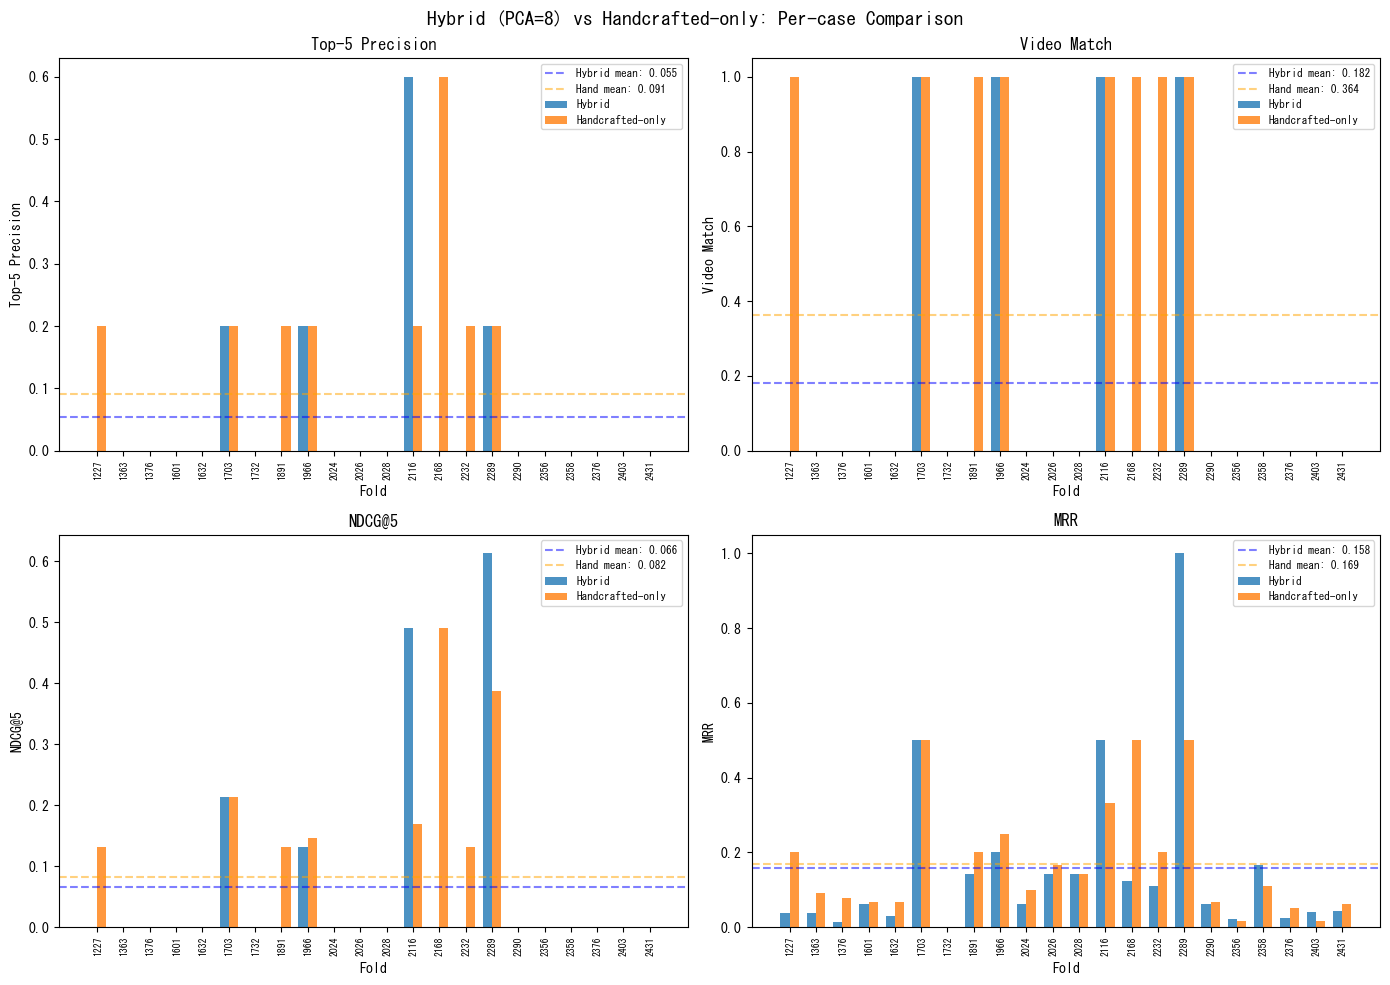

In [43]:
# ============================================================
# Cell 14: Per-case Analysis Visualization
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics_to_plot = [
    ('top5_precision', 'Top-5 Precision'),
    ('video_match', 'Video Match'),
    ('ndcg_at_5', 'NDCG@5'),
    ('mrr', 'MRR'),
]

for ax, (col, title) in zip(axes.flat, metrics_to_plot):
    x = np.arange(len(hybrid_results))
    w = 0.35
    ax.bar(x - w/2, hybrid_results[col].values, w, label='Hybrid', alpha=0.8)
    ax.bar(x + w/2, handcrafted_results[col].values, w, label='Handcrafted-only', alpha=0.8)
    ax.axhline(y=hybrid_results[col].mean(), color='blue', linestyle='--', alpha=0.5,
               label=f'Hybrid mean: {hybrid_results[col].mean():.3f}')
    ax.axhline(y=handcrafted_results[col].mean(), color='orange', linestyle='--', alpha=0.5,
               label=f'Hand mean: {handcrafted_results[col].mean():.3f}')
    ax.set_xlabel('Fold')
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(hybrid_results['case_id'].values, rotation=90, fontsize=7)

plt.suptitle(f'Hybrid (PCA={best_dim}) vs Handcrafted-only: Per-case Comparison', fontsize=14)
plt.tight_layout()
plt.show()

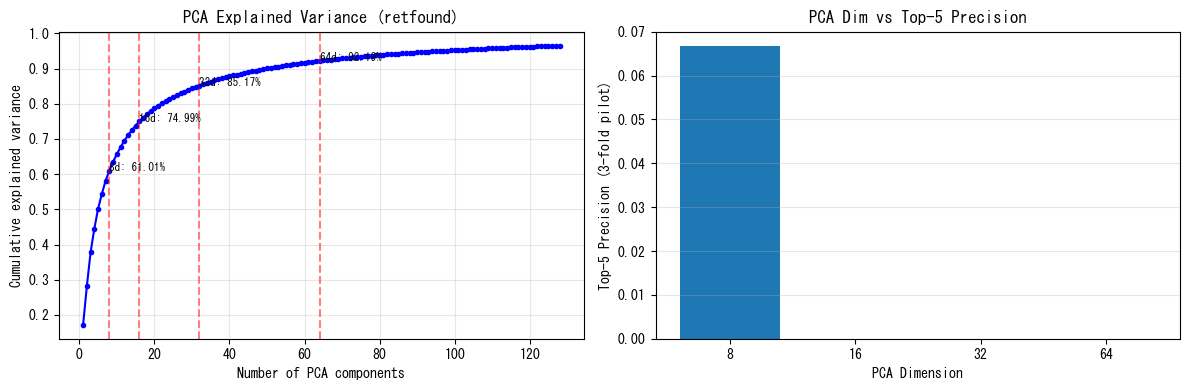

Explained variance at best PCA dim (8): 61.01%


In [44]:
# ============================================================
# Cell 15: PCA Component Analysis
# ============================================================

# Fit PCA on all data to analyze explained variance
all_candidates = []
for cid in case_ids:
    all_candidates.append(get_top_k_candidates(df, cid, config))
all_cand_df = pd.concat(all_candidates, ignore_index=True)

# Get CNN features for all candidates
zero_vec = np.zeros(config.cnn_feature_dim, dtype=np.float32)
cnn_matrix = np.stack([cnn_features.get(name, zero_vec) for name in all_cand_df['image_name']], axis=0)

# StandardScaler + PCA with more components for analysis
scaler_all = StandardScaler()
cnn_scaled = scaler_all.fit_transform(cnn_matrix)
pca_all = PCA(n_components=min(128, cnn_scaled.shape[0], cnn_scaled.shape[1]))
pca_all.fit(cnn_scaled)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Explained variance ratio
axes[0].plot(range(1, len(pca_all.explained_variance_ratio_) + 1),
             np.cumsum(pca_all.explained_variance_ratio_), 'b-o', markersize=3)
for dim in pca_dims_to_test:
    if dim <= len(pca_all.explained_variance_ratio_):
        cum_var = np.cumsum(pca_all.explained_variance_ratio_)[dim - 1]
        axes[0].axvline(x=dim, color='red', linestyle='--', alpha=0.5)
        axes[0].annotate(f'{dim}d: {cum_var:.2%}', xy=(dim, cum_var),
                        fontsize=8, ha='left')
axes[0].set_xlabel('Number of PCA components')
axes[0].set_ylabel('Cumulative explained variance')
axes[0].set_title(f'PCA Explained Variance ({config.backbone})')
axes[0].grid(True, alpha=0.3)

# PCA search results
dims = list(pca_search_results.keys())
precs = [pca_search_results[d]['top5_precision'] for d in dims]
axes[1].bar(range(len(dims)), precs, tick_label=[str(d) for d in dims])
axes[1].set_xlabel('PCA Dimension')
axes[1].set_ylabel('Top-5 Precision (3-fold pilot)')
axes[1].set_title('PCA Dim vs Top-5 Precision')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f'Explained variance at best PCA dim ({best_dim}): '
      f'{np.cumsum(pca_all.explained_variance_ratio_)[best_dim - 1]:.2%}')

In [45]:
# ============================================================
# Cell 16: Save Results
# ============================================================

output_dir = config.output_dir
output_dir.mkdir(parents=True, exist_ok=True)

# Save CV results with backbone name
hybrid_results.to_csv(output_dir / f'hybrid_{config.backbone}_lovo_cv_results.csv', index=False)
handcrafted_results.to_csv(output_dir / 'handcrafted_only_lovo_cv_results.csv', index=False)

# Save comparison table
comp_df.to_csv(output_dir / 'all_methods_comparison.csv')

# Save PCA search results
pca_df = pd.DataFrame(pca_search_results).T
pca_df.index.name = 'pca_dim'
pca_df.to_csv(output_dir / f'pca_dim_search_{config.backbone}.csv')

print(f'Results saved to {output_dir}/')
print()

# Final summary
print('=' * 60)
print(f'FINAL SUMMARY (backbone={config.backbone})')
print('=' * 60)
print()
print(comp_df.to_string(float_format='{:.4f}'.format))
print()
print(f'Best PCA dimension: {best_dim}')
print(f'Hybrid ({config.backbone}) Top-5 Precision: {hybrid_results["top5_precision"].mean():.4f}')
print(f'Handcrafted-only Top-5 Precision: {handcrafted_results["top5_precision"].mean():.4f}')
print(f'Rule-based Top-5 Precision: 0.5450')

Results saved to C:\Users\ykita\ROP_AI_project\ROP_project\bestimage_validation\hybrid_ranking_outputs/

FINAL SUMMARY (backbone=retfound)

                                      top5_precision  video_match  ndcg_at_5    mrr
Method                                                                             
Rule-based (retina+mbss)                      0.5450       0.8640     0.5100 0.6400
Feature MLP (15->64->32->16->1)               0.1910       0.5000     0.2120 0.3740
Hybrid EfficientNet-B0+Hand (PCA=64)          0.0818       0.3182     0.1012 0.2338
Handcrafted-only MLP (15->32->16->1)          0.0909       0.3636     0.0819 0.1692
Hybrid RETFound+Hand (PCA=8)                  0.0545       0.1818     0.0659 0.1576

Best PCA dimension: 8
Hybrid (retfound) Top-5 Precision: 0.0545
Handcrafted-only Top-5 Precision: 0.0909
Rule-based Top-5 Precision: 0.5450
